This notebook performs pre-processing of bin2cell spatial data and corresponding single-cell RNA-seq data.

In [ ]:
# IMPORT NASH 

In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
from anndata import AnnData
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import skimage
import seaborn as sns
import tangram as tg
import multiprocessing
import datetime
import multiprocessing
from collections import Counter
import os

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

%load_ext autoreload
%autoreload 2
%matplotlib inline

2024-11-08 14:37:07.519508: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-08 14:37:29.388802: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-08 14:37:29.388877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-08 14:37:32.766783: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-08 14:37:38.243483: I tensorflow/core/platform/cpu_feature_guar

scanpy==1.10.1 anndata==0.10.8 umap==0.5.6 numpy==1.26.4 scipy==1.14.1 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.3 igraph==0.11.6 pynndescent==0.5.13
squidpy==1.6.1


# Set parameters

In [2]:
sc_cells = 20000
sp_cells = 10000
gene_nums = 50

export_dir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/20241108_tangram_preprocessing_genelist50_liver_nash_rem_mast/'

if not os.path.isdir(export_dir):
    os.mkdir(export_dir)

print(export_dir)

# key = '20240918_genelist_50'

/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/20241108_tangram_preprocessing_genelist50_liver_nash_rem_mast/


In [3]:
# MASL liver output from Charlene's bin2cell run

# adata = sc.read_h5ad('/tscc/lustre/ddn/scratch/tvashist/charlene/bin2cell_out/bin2cell_jl101/HL180801/HL180801_cdata_b2c.h5ad')
adata = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/QY_2665_1_2/QY_2665_1_2_cdata_b2c_clust.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 530884 × 18028
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'clusters_colors', 'hvg', 'labels_joint_source_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obs.head()

,bin_count,array_row,array_col,labels_joint_source,clusters
1,46,305.043478,333.478261,primary,0
2,35,391.171429,221.971429,primary,0
3,7,291.428571,107.714286,primary,25
4,39,411.897436,291.897436,primary,0
7,38,392.500000,215.315789,primary,0


In [6]:
adata.var.head()

,gene_ids,feature_types,genome,n_cells,highly_variable,means,dispersions,dispersions_norm
SAMD11,ENSG00000187634,Gene Expression,GRCh38,351,False,0.000259,0.832560,-0.560863
NOC2L,ENSG00000188976,Gene Expression,GRCh38,1452,False,0.000873,0.763250,-0.654424
KLHL17,ENSG00000187961,Gene Expression,GRCh38,441,False,0.000338,1.204590,-0.058662
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38,77,False,0.000066,0.494538,-1.017157
PERM1,ENSG00000187642,Gene Expression,GRCh38,52,False,0.000043,0.695689,-0.745624


### Visualize spatial image from bin2cell output

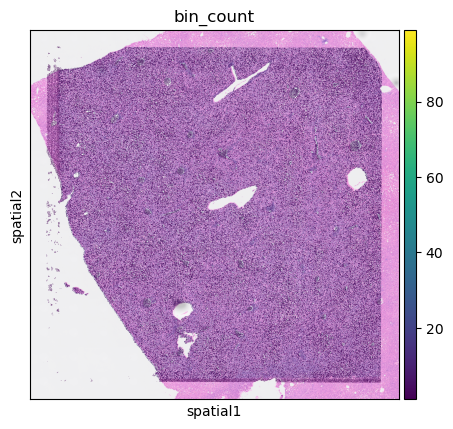

In [7]:
sc.pl.spatial(adata, color="bin_count")

In [12]:
coordinates = adata.obsm['spatial']

# Define the coordinate bounds for trimming (e.g., x_min, x_max, y_min, y_max)
x_min, x_max = 2000, 7000  # Define your own range
y_min, y_max = 2000, 7000  # Define your own range

# Filter the cells based on the defined bounds
cells_in_bounds = (coordinates[:, 0] >= x_min) & (coordinates[:, 0] <= x_max) & \
                  (coordinates[:, 1] >= y_min) & (coordinates[:, 1] <= y_max)
# Subset the AnnData object with the filtered cells
adata_trimmed = adata[cells_in_bounds, :]

In [10]:
coordinates

array([[1194.48824759, 1833.17584099],
       [ 970.41579383, 2005.01448424],
       [ 742.07774537, 1804.32512048],
       ...,
       [6741.86095436, 7120.29020697],
       [6658.73520237, 7693.04765273],
       [6511.06504792, 7515.22979359]])

In [11]:
# Check the min and max values
min_coords = np.min(coordinates, axis=0)
max_coords = np.max(coordinates, axis=0)

print(f"Min coordinates: {min_coords}")
print(f"Max coordinates: {max_coords}")

Min coordinates: [ 513.24827925 1220.21594741]
Max coordinates: [7238.37316189 7953.03282826]


### Trim the coordinates of the spatial image

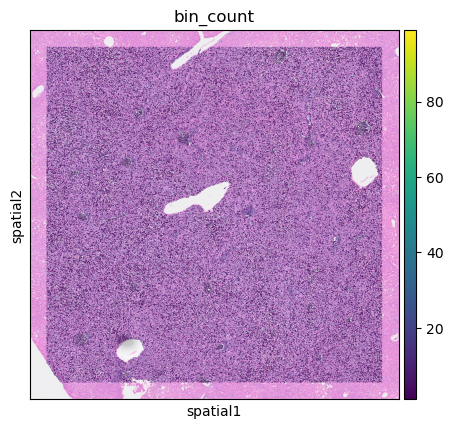

In [13]:
sc.pl.spatial(adata_trimmed, color="bin_count")  # View the trimmed image to confirm

### Downsample the number of cells in the spatial data

In [27]:
adata_downsampled = adata_trimmed.copy()   # Make a deep copy of adata_trimmed
# adata_downsampled = adata.copy()             # If you're not trimming the image

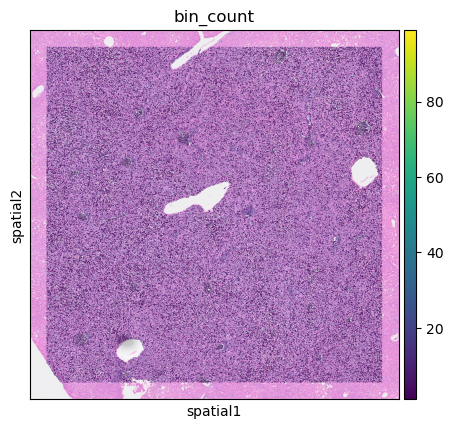

In [28]:
sc.pl.spatial(adata_downsampled, color="bin_count")

In [29]:
# User input: Set n_obs to the number of cells you want to downsample to.

sc.pp.subsample(adata_downsampled, n_obs=sp_cells, random_state=42)   
adata_downsampled

AnnData object with n_obs × n_vars = 10000 × 18028
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'clusters_colors', 'hvg', 'labels_joint_source_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

### Filter the spatial data

Because this is bin2cell output data, I will refer to each obs/bin as an individual cell.

In [30]:
# Calculate QC metrics for each cell in the data

adata_downsampled.var_names_make_unique()
adata_downsampled.var["mt"] = adata_downsampled.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata_downsampled, qc_vars=["mt"], inplace=True)

In [31]:
# Look at the data after the QC metrics have been calculated

adata_downsampled

AnnData object with n_obs × n_vars = 10000 × 18028
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'clusters', 'clusters_colors', 'hvg', 'labels_joint_source_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [32]:
# Filter out low quality bins/cells. This is what I approximate to follow what Mai did to filter out specific cells in her spatial data.

# Keep cells with > 100 counts and > 3 genes, can only provide one filter per call
sc.pp.filter_cells(adata_downsampled, min_counts = 1)                 # By counts
sc.pp.filter_cells(adata_downsampled, min_genes = 3)                    # By genes
adata_downsampled = adata_downsampled[adata_downsampled.obs["pct_counts_mt"] < 5].copy()       # Percent mitochondrial reads < 5

print(f"Number of cells after all filters: {adata_downsampled.n_obs}")

Number of cells after all filters: 4737


In [ ]:
# instead of 100 counts used 1 counts

# Single-cell data

In [3]:
# Condition-specific AnnData scRNA-seq object (Normal, MASH, MAFLD)

#ad_sc = sc.read_h5ad('/tscc/nfs/home/tvashist/liver/condition_h5ad/MASH.h5ad')
ad_sc = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/spatial_scr/condition_h5ad/MASH.h5ad')

In [4]:
ad_sc

AnnData object with n_obs × n_vars = 88203 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'donor_demux', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'seurat_clusters', 'log_nCount_SCT', 'log_nFeature_SCT', 'lane', 'batch', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'condition', 'disease_sta

In [ ]:
## rename the celltypes for T/NK
## remove schwann and mast
## then downsample

In [5]:
ad_sc.obs.celltype.value_counts() 

celltype
Hepatocytes      42878
Endothelial      13134
Myeloid          11388
HSC              10280
T                 3373
Cholangiocyte     3362
B                 1845
NK                1705
Schwann            134
Mast               104
Name: count, dtype: int64

In [6]:
ad_sc.obs['celltype'] = ad_sc.obs['celltype'].replace({'T': 'T_NK', 'NK': 'T_NK'})


In [8]:
ad_sc.obs.celltype.value_counts() 

celltype
Hepatocytes      42878
Endothelial      13134
Myeloid          11388
HSC              10280
T_NK              5078
Cholangiocyte     3362
B                 1845
Schwann            134
Mast               104
Name: count, dtype: int64

In [9]:
ad_sc = ad_sc[~ad_sc.obs['celltype'].isin(['Schwann', 'Mast'])]


In [10]:
ad_sc

View of AnnData object with n_obs × n_vars = 87965 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'donor_demux', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'seurat_clusters', 'log_nCount_SCT', 'log_nFeature_SCT', 'lane', 'batch', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'condition', 'dis

In [11]:
88203-87965

238

In [12]:
ad_sc.obs.celltype.value_counts() 

celltype
Hepatocytes      42878
Endothelial      13134
Myeloid          11388
HSC              10280
T_NK              5078
Cholangiocyte     3362
B                 1845
Name: count, dtype: int64

In [18]:
#ad_sc

In [20]:
#ad_sc.obs.condition.value_counts() 

### Downsample the scRNA-seq data

In [14]:
ad_sc_downsampled = ad_sc.copy()

In [15]:
# User input: Set n_obs to number of cells to keep

sc.pp.subsample(ad_sc_downsampled, n_obs=sc_cells, random_state=42)
ad_sc_downsampled

AnnData object with n_obs × n_vars = 20000 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'donor_demux', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'seurat_clusters', 'log_nCount_SCT', 'log_nFeature_SCT', 'lane', 'batch', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'condition', 'disease_sta

In [16]:
ad_sc = ad_sc_downsampled.copy()

In [21]:
print(ad_sc.X.dtype)
ad_sc.X = ad_sc.X.astype(int)

float64


In [22]:
ad_sc.obs.celltype.value_counts()   # The broad cell type annotations we want to use are listed in the spatial_annotations column

celltype
Hepatocytes      9763
Endothelial      3000
Myeloid          2617
HSC              2327
T_NK             1137
Cholangiocyte     763
B                 393
Name: count, dtype: int64

In [23]:
ad_sc  # Confirm that the object is appropriately downsampled

AnnData object with n_obs × n_vars = 20000 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'donor_demux', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'seurat_clusters', 'log_nCount_SCT', 'log_nFeature_SCT', 'lane', 'batch', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'condition', 'disease_sta

### Normalize and transform single-cell data

In [24]:
sc.pp.normalize_total(ad_sc, inplace=True)
sc.pp.log1p(ad_sc)
sc.pp.highly_variable_genes(ad_sc, flavor="seurat", n_top_genes=2000, inplace=True)

# Prepare training gene list

In [46]:
# Find genes found in both the single-cell and spatial data

markers = list(set.intersection(set(ad_sc.var_names), set(ad_sp.var_names)))
len(markers)

18025

In [ ]:
# use cellltype

In [25]:
sc.tl.rank_genes_groups(ad_sc, groupby="celltype", use_raw=False) # Rank the top 150 genes that distinguish each cell type in spatial_annotations

In [26]:
markers_df = pd.DataFrame(ad_sc.uns["rank_genes_groups"]["names"]).iloc[0:gene_nums, :]
markers_df.head()

,B,Cholangiocyte,Endothelial,HSC,Hepatocytes,Myeloid,T_NK
0,FBXW7,BICC1,LDB2,PRKG1,AL391117.1,SLC8A1,PTPRC
1,SEL1L3,PKHD1,PTPRB,RBMS3,CP,ZEB2,PARP8
2,FCRL5,GLIS3,ST6GALNAC3,CALD1,PIK3C2G,FMNL2,SKAP1
3,GLCCI1,CTNND2,FBXL7,ZFPM2,A1CF,TBXAS1,CELF2
4,MEF2C,ANXA4,PPFIBP1,IGFBP7,APOB,CD163,ARHGAP15


In [27]:
markers_df

# LDB2, PTPRB, ST6GALNAC3, FBXL7, PPFIBP1, KALRN, PLCB1, PREX2, APP	

# PTPRC, PARP8, SKAP1, CELF2, ARHGAP15, FYN, MBNL1, ANKRD44, PRKCH, PIP4K2A

# FBXW7, SEL1L3, FCRL5, GLCCI1, MEF2C, TPD52, FUT8, CDK14, MSI2, IFNG-AS1, RALGPS2	

,B,Cholangiocyte,Endothelial,HSC,Hepatocytes,Myeloid,T_NK
0,FBXW7,BICC1,LDB2,PRKG1,AL391117.1,SLC8A1,PTPRC
1,SEL1L3,PKHD1,PTPRB,RBMS3,CP,ZEB2,PARP8
2,FCRL5,GLIS3,ST6GALNAC3,CALD1,PIK3C2G,FMNL2,SKAP1
3,GLCCI1,CTNND2,FBXL7,ZFPM2,A1CF,TBXAS1,CELF2
4,MEF2C,ANXA4,PPFIBP1,IGFBP7,APOB,CD163,ARHGAP15
5,TPD52,THSD4,KALRN,LAMA2,ACSM2B,MSR1,FYN
6,FUT8,MAGI1,PLCB1,ANK3,ASGR1,DOCK2,MBNL1
7,CDK14,FGFR2,PREX2,PDE3A,PLG,KCNMA1,ANKRD44
8,MSI2,DCDC2,APP,NR2F2-AS1,SLCO1B1,PTPRC,PRKCH
9,IFNG-AS1,PTPRK,ERG,ADAMTS12,C5,CTSB,PIP4K2A


In [28]:
markers_df.shape # Check out dimensions

(50, 7)

In [29]:
markers = list(np.unique(markers_df.melt().value.values))   # Create an array of the unique markers across all the cell types
len(markers)

330

In [30]:

len(markers)

330

# Export pre-processed spatial and single-cell data

In [52]:
ad_sc

AnnData object with n_obs × n_vars = 20000 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'donor_demux', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'seurat_clusters', 'log_nCount_SCT', 'log_nFeature_SCT', 'lane', 'batch', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'condition', 'disease_sta

In [31]:
# I was getting a bunch of errors initially, this is what somehow helped me save the single-cell data correctly

ad_sc.__dict__['_raw'].__dict__['_var'] = ad_sc.__dict__['_raw'].__dict__['_var'].rename(columns={'_index': 'features'})

In [32]:
# Write out the preprocessed objects to be fed into a python script that runs tangram

ad_sc.write(export_dir + 'Preprocessed_adsc.h5ad')
#ad_sp.write(export_dir + 'Preprocessed_adsp.h5ad')

file = open(export_dir +'markers','w')
for item in markers:
	file.write(item+"\n")
file.close()